# ML4SA Lab 3

## Objectives:

1. Use distilled dataset from Lab 2 to train CORINE classifier on the target Area-of-Interest using three different classification methods
2. Predict CORINE classes on the target Area-of-Interest
3. Construct Confusion matrices for the three classification methods
4. Select the best classification method and construct CORINE classification raster map of the target Area-of-Interest



In [1]:
!git clone https://github.com/klaudiakosciukk/agh-habitat-pl.git
!pip -q install earthengine-api geemap
%cd agh-habitat-pl

Cloning into 'agh-habitat-pl'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 76 (delta 25), reused 31 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 813.51 KiB | 9.35 MiB/s, done.
Resolving deltas: 100% (25/25), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.8 MB/s eta 0:00:00
/content/agh-habitat-pl


In [3]:
from google.colab import userdata
import sys
import ee, geemap
sys.path.append('/content/agh-habitat-pl/src')

In [4]:
try:
    ee.Initialize(project='lukiim')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='lukiim')

Task - start

In [5]:
import ee, geemap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import random

import habitat_pl.viz.corine as corine
from importlib import reload as _reload; _ = _reload(corine)


YEAR = 2021
MAX_PER_CLASS = 250
SEED = 42
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 25
UMAP_MIN_DIST = 0.1
SCALE = 100
SAMPLES_PER_CLASS_RAW = 500
MAX_PER_CLASS_FINAL = 300
MAX_PER_CLASS_TILE = 200
random.seed(SEED); np.random.seed(SEED)



1. Define an AOI for well distinct, well defined surface classes \
In this case, we chose Rzeszów city - clear cut distinction between natural/urban landscape.


In [6]:
import ipywidgets as widgets
import habitat_pl.viz.corine as corine
import importlib

importlib.reload(corine)

region = (ee.FeatureCollection('FAO/GAUL/2015/level1')
          .filter(ee.Filter.eq('ADM1_NAME', 'Podkarpackie'))
          .geometry())

# Annual Satellite Embedding (example: 2021)
emb = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
       .filterDate('2021-01-01','2022-01-01')
       .filterBounds(region)
       .mosaic()
       .clip(region))

# Visualize (pseudo-RGB from embedding bands)
m = geemap.Map()
m.centerObject(region, 8)
m.addLayer(emb, {'min':-0.3,'max':0.3,'bands':['A01','A16','A09']}, 'Embeddings 2021')

# Loads CORINE Land Cover 2018 raster (44 classes, 100 m resolution).
clc = ee.Image('COPERNICUS/CORINE/V20/100m/2018').select('landcover').clip(region)

# Remaps CORINE class codes (111…523) to sequential indices (1…44).
clc_idx = clc.remap(corine.codes, list(range(1, len(corine.codes)+1))).rename('landcover_idx')

# Adds the CORINE raster to the map, colored according to EEA’s palette
m.addLayer(clc_idx, corine.vis, 'CORINE 2018')

# Creates a scrollable legend showing all 44 class names with their corresponding colors.
legend = m.add_legend(title="CORINE Land Cover 2018", legend_dict=corine.legend_dict)
m

Map(center=[49.95233161411762, 22.169400120254295], controls=(WidgetControl(options=['position', 'transparent_…

In [14]:
m.add_basemap('Esri.WorldImagery')
m

Map(bottom=22483.0, center=[50.15226627256271, 22.626342773437504], controls=(WidgetControl(options=['position…

In [19]:
aoi_feature = getattr(m, 'user_roi', None) or getattr(m, 'draw_last_feature', None)
if aoi_feature is None:
    raise ValueError("At first - draw polygon")

AOI = aoi_feature.geometry() if hasattr(aoi_feature, 'geometry') else aoi_feature
m.centerObject(AOI, 12)

2. Download GSE and CORINE labels for the defined AOI


In [20]:
# GSE
emb_img = (
    ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
    .filterDate(f'{YEAR}-01-01', f'{YEAR+1}-01-01')
    .filterBounds(AOI)
    .mosaic()
    .clip(AOI)
)

emb_bands = [f"A{i:02d}" for i in range(64)]
emb_img = emb_img.select(emb_bands)


In [21]:
clc_raw = ee.Image('COPERNICUS/CORINE/V20/100m/2018').select('landcover').clip(AOI)


clc_idx = clc_raw.rename('landcover_idx')


mask = clc_idx.gt(0)

emb_masked = emb_img.updateMask(mask)
stack = emb_masked.addBands(clc_idx)


classes_img = clc_idx.updateMask(mask)
present_idx = (
    classes_img
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=AOI,
        scale=SCALE,
        maxPixels=1e9
    )
    .get('landcover_idx')
)

present_idx = ee.Dictionary(present_idx).keys().map(lambda x: ee.Number.parse(x))
present_idx = present_idx.getInfo()
present_idx = sorted(set(int(v) for v in present_idx))
present_idx

[112, 122, 211, 231, 242, 243]

In [22]:
def sample_class(idx):
    img = stack.updateMask(clc_idx.eq(idx))
    return img.sample(
        region=AOI,
        scale=SCALE,
        numPixels=SAMPLES_PER_CLASS_RAW,
        seed=SEED,
        geometries=True,
    )

fc_list = [sample_class(i) for i in present_idx]
samples_fc = ee.FeatureCollection(fc_list).flatten()

fc_dict = samples_fc.getInfo()
features = fc_dict["features"]

rows = []
for f in features:
    props = f["properties"].copy()
    geom = f["geometry"]

    if geom["type"] == "Point":
        lon, lat = geom["coordinates"]
    else:

        coords = np.array(geom["coordinates"][0])
        lon = coords[:, 0].mean()
        lat = coords[:, 1].mean()

    props["longitude"] = lon
    props["latitude"] = lat
    rows.append(props)

df = pd.DataFrame(rows)
df = df.dropna().reset_index(drop=True)

print("Columns in df:", df.columns.tolist())
print(df.head())

Columns in df: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'landcover_idx', 'longitude', 'latitude']
        A00       A01       A02       A03       A04       A05       A06  \
0 -0.075356 -0.221453 -0.035433 -0.292872  0.153787 -0.119093  0.130165   
1 -0.007443 -0.236463  0.001538 -0.267958  0.124567 -0.071111  0.153787   
2 -0.044844 -0.276140 -0.032541 -0.259900  0.141730 -0.093564  0.113741   
3 -0.029773 -0.228897 -0.041584 -0.292872  0.119093 -0.108512  0.119093   
4 -0.029773 -0.228897 -0.041584 -0.292872  0.119093 -0.108512  0.119093   

        A07       A08       A09  ...       

In [25]:
import h3

cols = df.columns.tolist()
print("Kolumny w df:", cols)

lat_col, lon_col = "latitude", "longitude"


if hasattr(h3, "geo_to_h3"):

    def cell_fn(lat, lon, res):
        return h3.geo_to_h3(lat, lon, res)
    def parent_fn(h, res):
        return h3.h3_to_parent(h, res)
else:

    def cell_fn(lat, lon, res):
        return h3.latlng_to_cell(lat, lon, res)
    def parent_fn(h, res):
        return h3.cell_to_parent(h, res)

def latlon_to_h3(row, res):
    return cell_fn(row[lat_col], row[lon_col], res)


df["h3_z6"] = df.apply(lambda r: latlon_to_h3(r, 6), axis=1)


df["h3_z4"] = df["h3_z6"].apply(lambda h: parent_fn(h, 4))

print(df[["landcover_idx", "latitude", "longitude", "h3_z4", "h3_z6"]].head())
print("Number of classes:", df["landcover_idx"].nunique())
print("Classes H3 z4:", df["h3_z4"].nunique())


Kolumny w df: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'landcover_idx', 'longitude', 'latitude']
   landcover_idx   latitude  longitude            h3_z4            h3_z6
0            112  50.085120  21.841189  841e287ffffffff  861e2861fffffff
1            112  50.086018  21.840290  841e287ffffffff  861e2861fffffff
2            112  50.086018  21.842087  841e287ffffffff  861e2861fffffff
3            112  50.086916  21.842087  841e287ffffffff  861e2861fffffff
4            112  50.086916  21.842985  841e287ffffffff  861e2861fffffff
Number of classes: 6
Classes H3 z4: 1


In [26]:
def balance_per_tile(df_in, label_col="landcover_idx", tile_col="h3_z4",
                     max_per_class_tile=200, seed=42):
    parts = []
    for (tile, cls), sub in df_in.groupby([tile_col, label_col]):
        if len(sub) > max_per_class_tile:
            parts.append(sub.sample(max_per_class_tile, random_state=seed))
        else:
            parts.append(sub)
    out = pd.concat(parts, axis=0)
    out = out.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

df_bal = balance_per_tile(df)
print("Shape after balancing:", df_bal.shape)
print("Classes:", sorted(df_bal["landcover_idx"].unique()))

Shape after balancing: (393, 69)
Classes: [np.int64(112), np.int64(122), np.int64(211), np.int64(231), np.int64(242), np.int64(243)]


UMAP

In [27]:
import numpy as np
import umap
emb_cols = [f"A{i:02d}" for i in range(64)]

X = df_bal[emb_cols].values.astype("float32")
y = df_bal["landcover_idx"].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", np.unique(y))

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X)

df_umap = df_bal.copy()
df_umap["umap1"] = X_umap[:, 0]
df_umap["umap2"] = X_umap[:, 1]

df_umap.head()


X shape: (393, 64)
y shape: (393,)
Unique classes: [112 122 211 231 242 243]


,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,A61,A62,A63,landcover_idx,longitude,latitude,h3_z6,h3_z4,umap1,umap2
0,-0.119093,-0.153787,-0.160000,-0.236463,0.147697,-0.048228,0.124567,-0.003937,0.029773,0.006151,...,-0.062991,0.048228,0.166336,211,21.882511,50.101289,861e2861fffffff,841e287ffffffff,11.225551,-0.752264
1,-0.093564,-0.119093,-0.084214,-0.088827,0.048228,-0.318893,0.088827,0.236463,-0.055363,0.113741,...,-0.113741,-0.022207,0.029773,231,21.857358,50.087814,861e2861fffffff,841e287ffffffff,1.101796,-3.313525
2,-0.153787,-0.221453,-0.071111,-0.236463,0.119093,-0.124567,0.088827,0.015748,-0.071111,-0.059116,...,-0.088827,-0.024606,-0.038447,231,21.844782,50.083323,861e2861fffffff,841e287ffffffff,4.881601,-2.130912
3,-0.147697,-0.088827,-0.027128,-0.244152,0.130165,-0.141730,0.199862,0.022207,-0.055363,0.013841,...,-0.172795,-0.022207,0.113741,211,21.891494,50.086916,861e286e7ffffff,841e287ffffffff,5.396384,-1.607985
4,-0.098424,-0.062991,-0.135886,-0.113741,0.088827,-0.228897,0.108512,0.147697,0.015748,0.024606,...,-0.119093,-0.038447,0.010396,243,21.839392,50.108476,861e2861fffffff,841e287ffffffff,1.702608,-2.693170


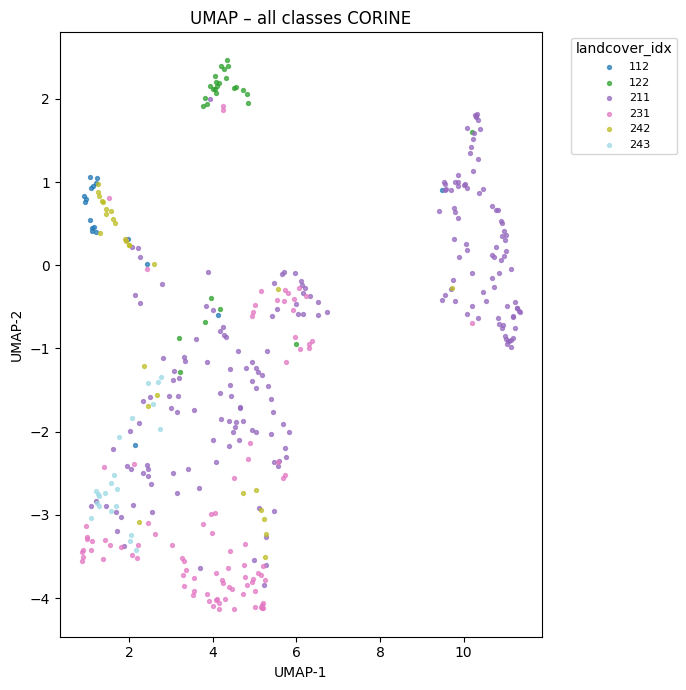

In [29]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

classes = np.sort(df_umap["landcover_idx"].unique())
num_classes = len(classes)
cmap = cm.get_cmap("tab20", num_classes)

plt.figure(figsize=(7, 7))

for i, cls in enumerate(classes):
    m = df_umap["landcover_idx"] == cls
    plt.scatter(
        df_umap.loc[m, "umap1"],
        df_umap.loc[m, "umap2"],
        s=8,
        alpha=0.7,
        label=str(int(cls)),
        c=[cmap(i)],
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP – all classes CORINE")
plt.legend(title="landcover_idx", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Available classes: [112 122 211 231 242 243]


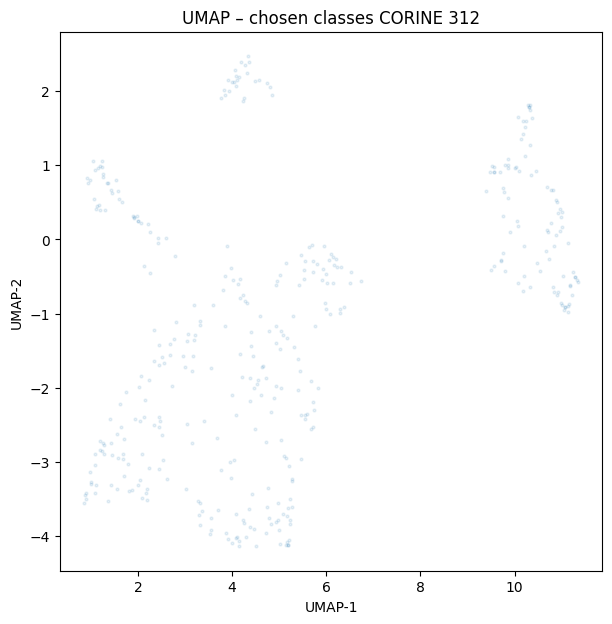

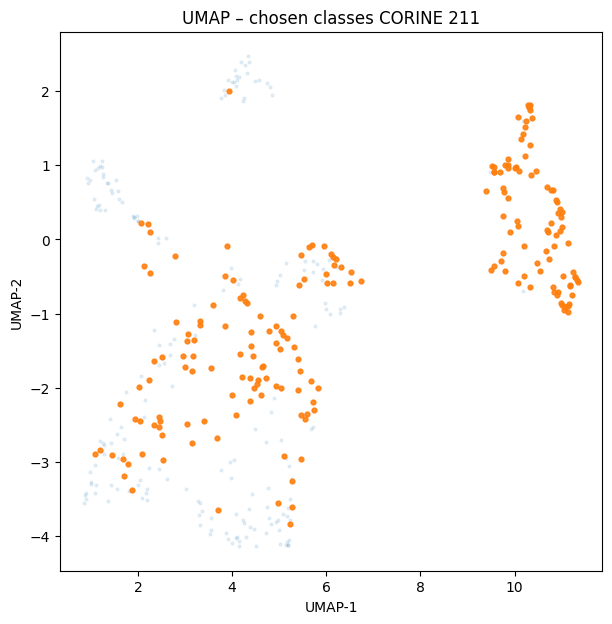

In [30]:
print("Available classes:", classes)

# ex. choosing 312 and 211
focus_classes = [312, 211]

for cls in focus_classes:
    m_focus = df_umap["landcover_idx"] == cls

    plt.figure(figsize=(7, 7))


    plt.scatter(
        df_umap.loc[~m_focus, "umap1"],
        df_umap.loc[~m_focus, "umap2"],
        s=4,
        alpha=0.1,
    )


    plt.scatter(
        df_umap.loc[m_focus, "umap1"],
        df_umap.loc[m_focus, "umap2"],
        s=12,
        alpha=0.9,
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title(f"UMAP – chosen classes CORINE {cls}")
    plt.show()


##UMAP mapping to the distilled training dataset


In [32]:
import numpy as np
import pandas as pd

SEED = globals().get("SEED", 42)
MAX_PER_CLASS_FINAL = globals().get("MAX_PER_CLASS_FINAL", 300)

LABEL = "landcover_idx"
EMB_COLS = [f"A{i:02d}" for i in range(64)]  # A00..A63

if "df_distilled" not in globals():
    base_df = df_umap.copy() if "df_umap" in globals() else df_bal.copy()

    # Remove outliers
    if "is_outlier_svm" in base_df.columns:
        base_df = base_df.loc[~base_df["is_outlier_svm"]].copy()

    # distilled: limit per class
    df_distilled = (
        base_df.groupby(LABEL, group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), MAX_PER_CLASS_FINAL), random_state=SEED))
        .reset_index(drop=True)
    )

print("df_distilled shape:", df_distilled.shape)
print("classes:", sorted(df_distilled[LABEL].unique())[:10], "...")
print("counts head:\n", df_distilled[LABEL].value_counts().head(10))


df_distilled shape: (393, 71)
classes: [np.int64(112), np.int64(122), np.int64(211), np.int64(231), np.int64(242), np.int64(243)] ...
counts head:
 landcover_idx
211    200
231     97
242     28
122     28
243     22
112     18
Name: count, dtype: int64


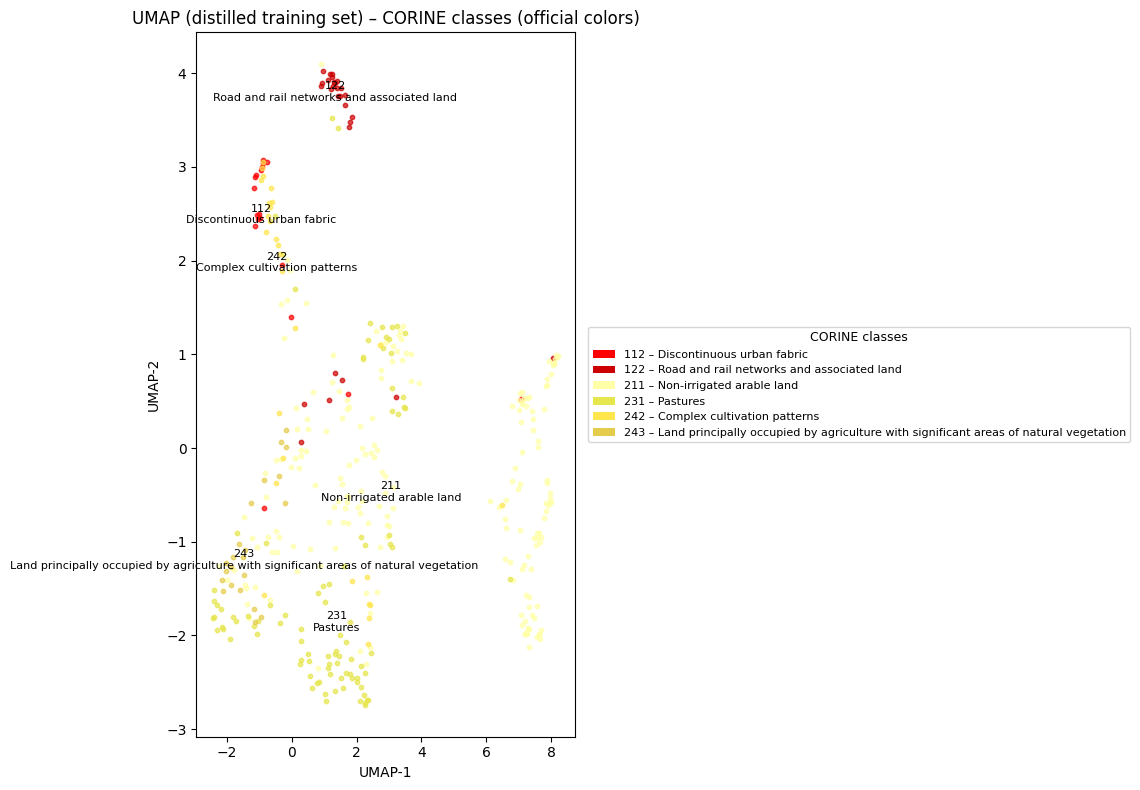

In [37]:
import umap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

LABEL = "landcover_idx"
EMB_COLS = [f"A{i:02d}" for i in range(64)]

# Official CORINE color palette
CLC = [
    (111, "#e6004d", "Continuous urban fabric"),
    (112, "#ff0000", "Discontinuous urban fabric"),
    (121, "#cc4df2", "Industrial or commercial units"),
    (122, "#cc0000", "Road and rail networks and associated land"),
    (123, "#e6cccc", "Port areas"),
    (124, "#e6cce6", "Airports"),
    (131, "#a600cc", "Mineral extraction sites"),
    (132, "#a64d00", "Dump sites"),
    (133, "#ff4dff", "Construction sites"),
    (141, "#ffa6ff", "Green urban areas"),
    (142, "#ffe6ff", "Sport and leisure facilities"),
    (211, "#ffffa8", "Non-irrigated arable land"),
    (212, "#ffff00", "Permanently irrigated land"),
    (213, "#e6e600", "Rice fields"),
    (221, "#e68000", "Vineyards"),
    (222, "#f2a64d", "Fruit trees and berry plantations"),
    (223, "#e6a600", "Olive groves"),
    (231, "#e6e64d", "Pastures"),
    (241, "#ffe6a6", "Annual crops associated with permanent crops"),
    (242, "#ffe64d", "Complex cultivation patterns"),
    (243, "#e6cc4d", "Land principally occupied by agriculture with significant areas of natural vegetation"),
    (244, "#f2cca6", "Agro-forestry areas"),
    (311, "#80ff00", "Broad-leaved forest"),
    (312, "#00a600", "Coniferous forest"),
    (313, "#4dff00", "Mixed forest"),
    (321, "#ccf24d", "Natural grasslands"),
    (322, "#a6ff80", "Moors and heathland"),
    (323, "#a6e64d", "Sclerophyllous vegetation"),
    (324, "#a6f200", "Transitional woodland-shrub"),
    (331, "#e6e6e6", "Beaches - dunes - sands"),
    (332, "#cccccc", "Bare rocks"),
    (333, "#ccffcc", "Sparsely vegetated areas"),
    (334, "#000000", "Burnt areas"),
    (335, "#a6e6cc", "Glaciers and perpetual snow"),
    (411, "#a6a6ff", "Inland marshes"),
    (412, "#4d4dff", "Peat bogs"),
    (421, "#ccccff", "Salt marshes"),
    (422, "#e6e6ff", "Salines"),
    (423, "#a6a6e6", "Intertidal flats"),
    (511, "#00ccf2", "Water courses"),
    (512, "#80f2e6", "Water bodies"),
    (521, "#00ffa6", "Coastal lagoons"),
    (522, "#a6ffe6", "Estuaries"),
    (523, "#e6f2ff", "Sea and ocean"),
]

CLC_COLOR = {code: col for code, col, _ in CLC}
CLC_NAME  = {code: name for code, _, name in CLC}

# --- UMAP na distilled dataset ---
X = df_distilled[EMB_COLS].values.astype("float32")
y = df_distilled[LABEL].values.astype(int)

reducer = umap.UMAP(
    n_neighbors=globals().get("UMAP_N_NEIGHBORS", 30),
    min_dist=globals().get("UMAP_MIN_DIST", 0.1),
    n_components=2,
    metric="euclidean",
    random_state=globals().get("SEED", 42),
)

Z = reducer.fit_transform(X)

df_umap_distilled = df_distilled.copy()
df_umap_distilled["umap1"] = Z[:, 0]
df_umap_distilled["umap2"] = Z[:, 1]

#Plot: class with CORINE
classes = np.sort(df_umap_distilled[LABEL].unique())

plt.figure(figsize=(11, 8))

# scatter per class
for cls in classes:
    m = df_umap_distilled[LABEL] == cls
    color = CLC_COLOR.get(int(cls), "#777777")
    plt.scatter(
        df_umap_distilled.loc[m, "umap1"],
        df_umap_distilled.loc[m, "umap2"],
        s=10,
        alpha=0.70,
        c=color,
    )

# labels in centroid
for cls in classes:
    m = df_umap_distilled[LABEL] == cls
    x0 = float(df_umap_distilled.loc[m, "umap1"].median())
    y0 = float(df_umap_distilled.loc[m, "umap2"].median())
    name = CLC_NAME.get(int(cls), "")
    txt = f"{int(cls)}" if name == "" else f"{int(cls)}\n{name}"
    plt.text(x0, y0, txt, fontsize=8, ha="center", va="center")

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP (distilled training set) – CORINE classes (official colors)")

# Legend
legend_handles = []
for cls in classes:
    code = int(cls)
    color = CLC_COLOR.get(code, "#777777")
    name = CLC_NAME.get(code, "Unknown")
    legend_handles.append(Patch(facecolor=color, edgecolor="none", label=f"{code} – {name}"))

plt.legend(
    handles=legend_handles,
    title="CORINE classes",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    ncol=1,
)

plt.tight_layout()
plt.show()

##Confusion matrices

In [38]:
import numpy as np
from sklearn.model_selection import train_test_split

LABEL = "landcover_idx"
EMB_COLS = [f"A{i:02d}" for i in range(64)]  # A00..A63
SEED = 42

X = df_distilled[EMB_COLS].values.astype("float32")
y = df_distilled[LABEL].values.astype(int)

classes = np.sort(np.unique(y))

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Classes:", classes.tolist())


Train: (275, 64) Val: (118, 64)
Classes: [112, 122, 211, 231, 242, 243]


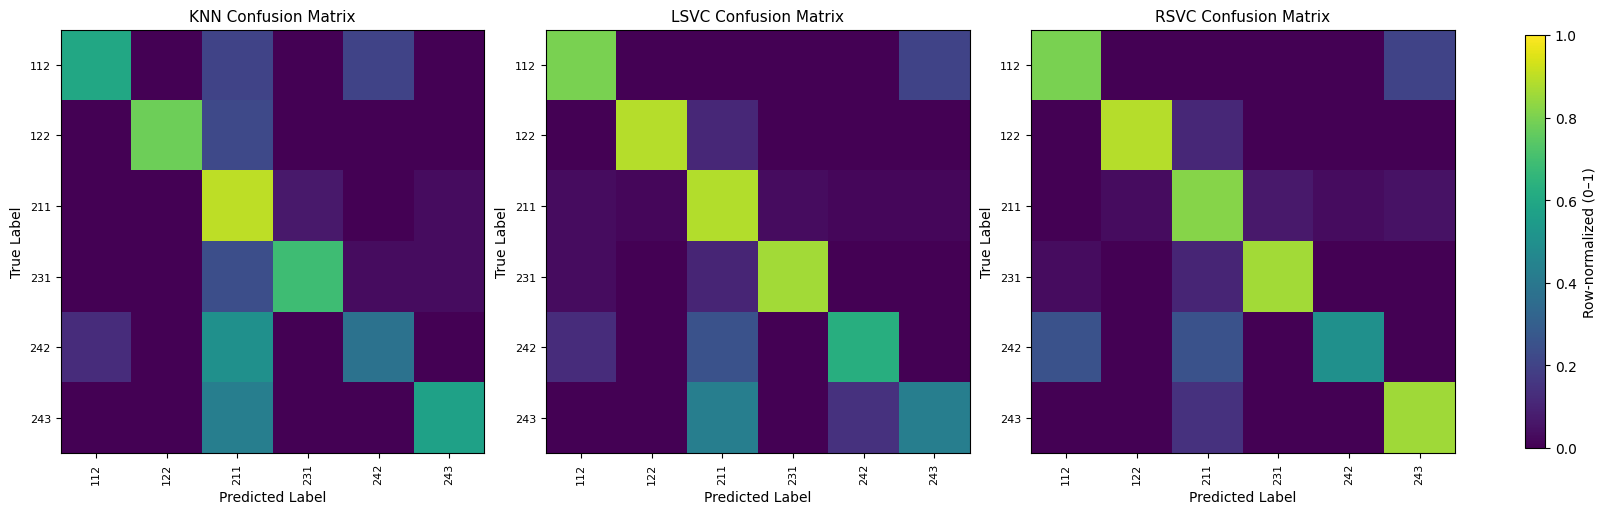

KNN  | acc=0.771 | balanced_acc=0.652 | f1_macro=0.692
LSVC | acc=0.831 | balanced_acc=0.748 | f1_macro=0.739
RSVC | acc=0.814 | balanced_acc=0.787 | f1_macro=0.749


In [39]:
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score

def row_normalize(cm: np.ndarray) -> np.ndarray:
    cm = cm.astype("float64")
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return cm / row_sum

def plot_cm(ax, cm_norm, title, labels):
    im = ax.imshow(cm_norm, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    return im

# Models definicitons
models = {
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights="distance")),
    "LSVC": make_pipeline(StandardScaler(), LinearSVC(C=2.0, class_weight="balanced", max_iter=5000, random_state=SEED)),
    "RSVC": make_pipeline(StandardScaler(), SVC(C=5.0, kernel="rbf", gamma="scale", class_weight="balanced")),
}

results = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)

    cm = confusion_matrix(y_val, y_pred, labels=classes)
    cm_norm = row_normalize(cm)

    results[name] = {
        "model": clf,
        "cm": cm,
        "cm_norm": cm_norm,
        "acc": accuracy_score(y_val, y_pred),
        "bacc": balanced_accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
    }

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

ims = []
for ax, (name, r) in zip(axes, results.items()):
    im = plot_cm(ax, r["cm_norm"], f"{name} Confusion Matrix", labels=classes)
    ims.append(im)

cbar = fig.colorbar(ims[-1], ax=axes, shrink=0.9)
cbar.set_label("Row-normalized (0–1)")

plt.show()

# Summary
for name, r in results.items():
    print(
        f"{name:4s} | acc={r['acc']:.3f} | balanced_acc={r['bacc']:.3f} | f1_macro={r['f1_macro']:.3f}"
    )


##Best classifier method

In [40]:
best_name = max(results.keys(), key=lambda k: results[k]["f1_macro"])
best_model = results[best_name]["model"]
print("Best model:", best_name, "| f1_macro:", results[best_name]["f1_macro"])


Best model: RSVC | f1_macro: 0.7488299009864078


In [46]:
import geemap
import ee
import numpy as np
import geojson

LABEL = "landcover_idx"
FEATURE_BANDS = [f"A{i:02d}" for i in range(64)]  # A00..A63

# Checking if df exist
if "df_distilled" not in globals():
    if "df_umap" in globals():
        df_distilled = df_umap.copy()
        if "is_outlier_svm" in df_distilled.columns:
            df_distilled = df_distilled.loc[~df_distilled["is_outlier_svm"]].copy()
    else:
        df_distilled = df_bal.copy()

# Detect which coordinate columns are available
coord_cols = None
for cand in [("longitude","latitude"), ("lon","lat"), ("x","y")]:
    if cand[0] in df_distilled.columns and cand[1] in df_distilled.columns:
        coord_cols = cand
        break

if coord_cols is None:
    raise ValueError("No coordinate columns found.")

lon_col, lat_col = coord_cols

# Keep only required columns
keep_cols = [lon_col, lat_col, LABEL] + FEATURE_BANDS
df_for_ee = df_distilled[keep_cols].dropna().copy()

# Ensure label and features have numeric types
df_for_ee[LABEL] = df_for_ee[LABEL].astype(int)
for c in FEATURE_BANDS:
    df_for_ee[c] = df_for_ee[c].astype(float)

# Convert pandas DataFrame
try:
    samples_fc_distilled = geemap.pandas_to_ee(df_for_ee, latitude=lat_col, longitude=lon_col)
except Exception:
    samples_fc_distilled = geemap.df_to_ee(df_for_ee, latitude=lat_col, longitude=lon_col)

print("samples_fc_distilled size:", samples_fc_distilled.size().getInfo())
print("Example keys:", ee.Feature(samples_fc_distilled.first()).toDictionary().keys().getInfo())


samples_fc_distilled size: 393
Example keys: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'landcover_idx', 'latitude', 'longitude']


In [51]:
import ee

LABEL = "landcover_idx"
FEATURE_BANDS = [f"A{i:02d}" for i in range(64)]
SEED = 42

# Split train/val
fc_rand = samples_fc_distilled.randomColumn("rand", seed=SEED)
train_fc = fc_rand.filter(ee.Filter.lt("rand", 0.7))
valid_fc = fc_rand.filter(ee.Filter.gte("rand", 0.7))

print("Train size:", train_fc.size().getInfo())
print("Valid size:", valid_fc.size().getInfo())
print("Using:", best_for_ee)

# Classifier
if best_for_ee == "LSVC":
    ee_clf = ee.Classifier.libsvm(kernelType="LINEAR", cost=2.0)
elif best_for_ee == "RSVC":
    ee_clf = ee.Classifier.libsvm(kernelType="RBF", cost=5.0, gamma=0.5)
else:
    raise ValueError("best_for_ee must be 'LSVC' or 'RSVC'")

# Train in EE
ee_clf = ee_clf.train(
    features=train_fc,
    classProperty=LABEL,
    inputProperties=FEATURE_BANDS
)

# Predict raster in AOI
pred_code = (
    emb_img.select(FEATURE_BANDS)
    .classify(ee_clf)
    .clip(AOI)
    .rename("clc_code")
)

# Quick validation
valid_pred = valid_fc.classify(ee_clf)
cm = valid_pred.errorMatrix(LABEL, "classification")
print("EE overall accuracy:", cm.accuracy().getInfo())


Train size: 261
Valid size: 132
Using: RSVC
EE overall accuracy: 0.803030303030303


In [57]:
import geemap

# Use class codes present
present_codes = sorted(samples_fc_distilled.aggregate_array(LABEL).distinct().getInfo())

palette = [CLC_COLOR.get(int(c), "#777777") for c in present_codes]
idx = list(range(len(present_codes)))

# Remap CORINE code
pred_idx = pred_code.remap(present_codes, idx).rename("clc_idx")

# Map
m_map = geemap.Map()
m_map.centerObject(AOI, 11)

m_map.addLayer(
    pred_idx,
    {"min": 0, "max": len(present_codes)-1, "palette": palette},
    f"CORINE prediction ({best_for_ee})",
    True
)

# Legend labels
CLC_NAME = {
  111:"Continuous urban fabric",112:"Discontinuous urban fabric",
  121:"Industrial or commercial units",122:"Road and rail networks and associated land",
  123:"Port areas",124:"Airports",
  131:"Mineral extraction sites",132:"Dump sites",133:"Construction sites",
  141:"Green urban areas",142:"Sport and leisure facilities",
  211:"Non-irrigated arable land",212:"Permanently irrigated land",213:"Rice fields",
  221:"Vineyards",222:"Fruit trees and berry plantations",223:"Olive groves",
  231:"Pastures",241:"Annual crops associated with permanent crops",
  242:"Complex cultivation patterns",
  243:"Land principally occupied by agriculture with significant areas of natural vegetation",
  244:"Agro-forestry areas",
  311:"Broad-leaved forest",312:"Coniferous forest",313:"Mixed forest",
  321:"Natural grasslands",322:"Moors and heathland",323:"Sclerophyllous vegetation",
  324:"Transitional woodland-shrub",
  331:"Beaches - dunes - sands",332:"Bare rocks",333:"Sparsely vegetated areas",
  334:"Burnt areas",335:"Glaciers and perpetual snow",
  411:"Inland marshes",412:"Peat bogs",421:"Salt marshes",422:"Salines",
  423:"Intertidal flats",
  511:"Water courses",512:"Water bodies",521:"Coastal lagoons",
  522:"Estuaries",523:"Sea and ocean",
}

# Legend for present classes
legend_keys = []
legend_colors = []

for code, col in zip(present_codes, palette):
    code = int(code)
    name = CLC_NAME.get(code, "Unknown")
    legend_keys.append(f"{code} – {name}")
    legend_colors.append(col)

m_map.add_legend(
    title="CORINE classes",
    labels=legend_keys,
    colors=legend_colors,
    position="bottomright",
)

m_map

Map(center=[50.097674549887465, 21.866920715395008], controls=(WidgetControl(options=['position', 'transparent…